# Home task : KNN classification
1. `iris` dataset
    - load `iris` dataset
    - split to train and test
    - train KNN classifiers for different `K`
    - choose the best `K` determined on test set

2. synthetic dataset
    - generrate synthetic dataset
    - split to train and test
    - train KNN regressors for different `K`
    - choose the best `K` determined on test set
    - visualize the decision boundary 




## `Iris` dataset 

In [2]:
import pandas as pd 
import numpy as np 
random_seed = np.random.seed = 2021
from sklearn.datasets import load_iris
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
iris = load_iris()
print ('data contains:',iris.keys())
X, y, labels, feature_names  = iris.data, iris.target, iris.target_names, iris['feature_names']
df_iris= pd.DataFrame(X, columns= feature_names) 
df_iris['label'] =  y
features_dict = {k:v for k,v in  enumerate(labels)}
df_iris['label_names'] = df_iris.label.apply(lambda x: features_dict[x])
df_iris

data contains: dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),label,label_names
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2,virginica
146,6.3,2.5,5.0,1.9,2,virginica
147,6.5,3.0,5.2,2.0,2,virginica
148,6.2,3.4,5.4,2.3,2,virginica


In [5]:
from sklearn.model_selection import train_test_split

def compute_best_k_and_score(X,y,random_seed, knn):
    
    results = []
    X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = random_seed) 

    for n in range(1, len(y_train)):
        neighbour = knn(n_neighbors=n)
        neighbour.fit(X_train, y_train)
        results.append({"n": n, "score": neighbour.score(X_test, y_test)})

    best_result = results[0]  
    
    for result in results:
        if result["score"] > best_result["score"]:
            best_result = result

    return best_result["n"], best_result["score"]

In [6]:
k_best, score_best = compute_best_k_and_score(X,y,random_seed, KNeighborsClassifier)
print ('The best k = {} , score = {}'.format(k_best,score_best ))

The best k = 8 , score = 1.0


## Synthetic dataset  

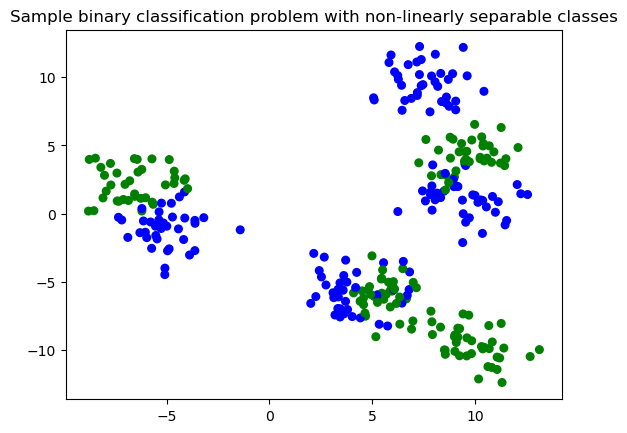

In [7]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
%matplotlib inline
from matplotlib.colors import ListedColormap
from sklearn.neighbors import KNeighborsRegressor
cmap_bold = ListedColormap(['blue','#FFFF00','black','green'])

np.random.seed= 2021
X_D2, y_D2 = make_blobs(n_samples = 300, n_features = 2, centers = 8,
                       cluster_std = 1.3, random_state = 4)
y_D2 = y_D2 % 2
plt.figure()
plt.title('Sample binary classification problem with non-linearly separable classes')
plt.scatter(X_D2[:,0], X_D2[:,1], c=y_D2,
           marker= 'o', s=30, cmap=cmap_bold)



In [11]:
k_best, score_best = compute_best_k_and_score(X_D2, y_D2, random_seed, KNeighborsRegressor)
print ('The best k = {} , score = {}'.format(k_best,score_best ))

The best k = 3 , score = 0.7447768281101614


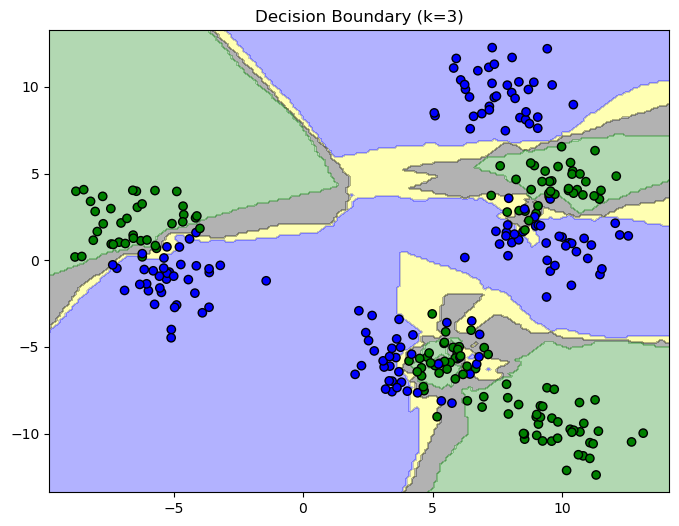

In [14]:
# visualize decision boundary 
x_min, x_max = X_D2[:, 0].min() - 1, X_D2[:, 0].max() + 1
y_min, y_max = X_D2[:, 1].min() - 1, X_D2[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

X_train, X_test, y_train, y_test = train_test_split(X_D2, y_D2, random_state=2021)
knn = KNeighborsRegressor(n_neighbors=k_best)
knn.fit(X_train, y_train)
Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Візуалізація
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=cmap_bold)
plt.scatter(X_D2[:, 0], X_D2[:, 1], c=y_D2, cmap=cmap_bold, edgecolor='k')
plt.title(f'Decision Boundary (k={knn.n_neighbors})')
plt.show()